In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data/Food_Delivery_Cleaned.csv")

In [2]:
data.describe()

,order_id,customer_id,delivery_time_minutes,quantity,price,discount,rating,revenue
count,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000
mean,1000.145153,1499.034154,36.092918,2.654445,172.163737,14.535912,2.981496,441.733300
std,577.620334,294.200984,17.807200,2.429742,71.534321,8.464385,1.376097,504.731641
min,1.000000,1000.000000,20.000000,1.000000,50.000000,0.000000,1.000000,27.000000
25%,500.500000,1232.000000,27.000000,1.000000,111.000000,7.000000,2.000000,199.000000
50%,999.000000,1503.000000,35.000000,3.000000,170.000000,15.000000,3.000000,350.000000
75%,1499.500000,1760.500000,42.000000,4.000000,233.500000,22.000000,4.000000,589.000000
max,2000.000000,1998.000000,292.000000,41.000000,299.000000,29.000000,5.000000,10405.000000


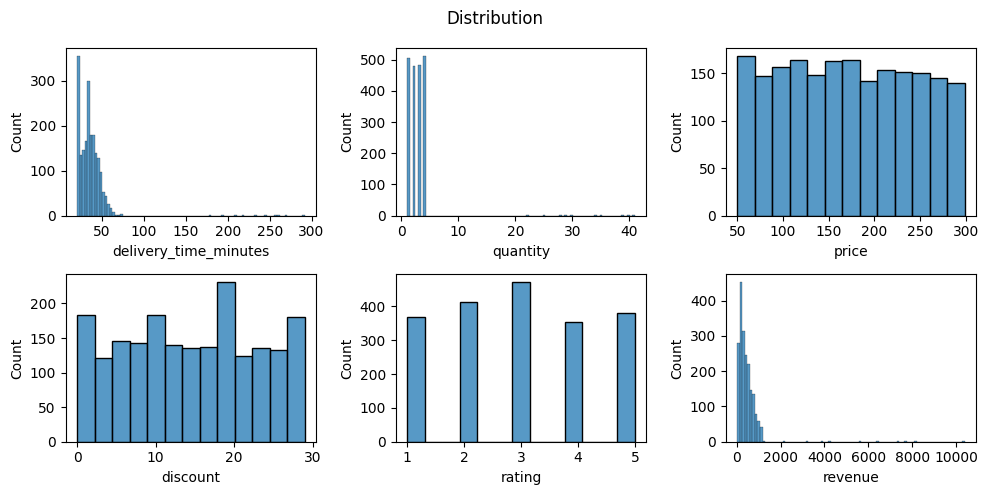

In [3]:
fig, ax = plt.subplots(2, 3, figsize = (10, 5))
sns.histplot(data["delivery_time_minutes"], ax = ax[0, 0])
sns.histplot(data["quantity"], ax = ax[0, 1])
sns.histplot(data["price"], ax = ax[0, 2])
sns.histplot(data["discount"], ax = ax[1, 0])
sns.histplot(data["rating"], ax = ax[1, 1])
sns.histplot(data["revenue"], ax = ax[1, 2])
fig.suptitle("Distribution")
plt.tight_layout();

In [4]:
print("Ranges:")
data.max(numeric_only = True) - data.min(numeric_only = True)

Ranges:


order_id                  1999.0
customer_id                998.0
delivery_time_minutes      272.0
quantity                    40.0
price                      249.0
discount                    29.0
rating                       4.0
revenue                  10378.0
dtype: float64

In [5]:
print("Spread(std):")
data.std(numeric_only = True)

Spread(std):


order_id                 577.620334
customer_id              294.200984
delivery_time_minutes     17.807200
quantity                   2.429742
price                     71.534321
discount                   8.464385
rating                     1.376097
revenue                  504.731641
dtype: float64

"price", "discount" and "rating" are balanced, while "delivery_time_minutes", "quantity" and "revenue" are "right skewed", due to the outliers which I retained.

In [16]:
for col in ["restaurant", "city", "item", "payment_method"]:
    print(data[col].value_counts())
    print("#" * 50)

restaurant
Kebab House    420
Pasta Point    414
Pizza Hub      391
Burger Town    387
Sushi World    379
Name: count, dtype: int64
##################################################
city
Cairo    1053
Alex      636
Giza      302
Name: count, dtype: int64
##################################################
item
Pizza     452
Pasta     402
Burger    391
Sushi     378
Kebab     368
Name: count, dtype: int64
##################################################
payment_method
Wallet    677
Cash      660
Card      654
Name: count, dtype: int64
##################################################


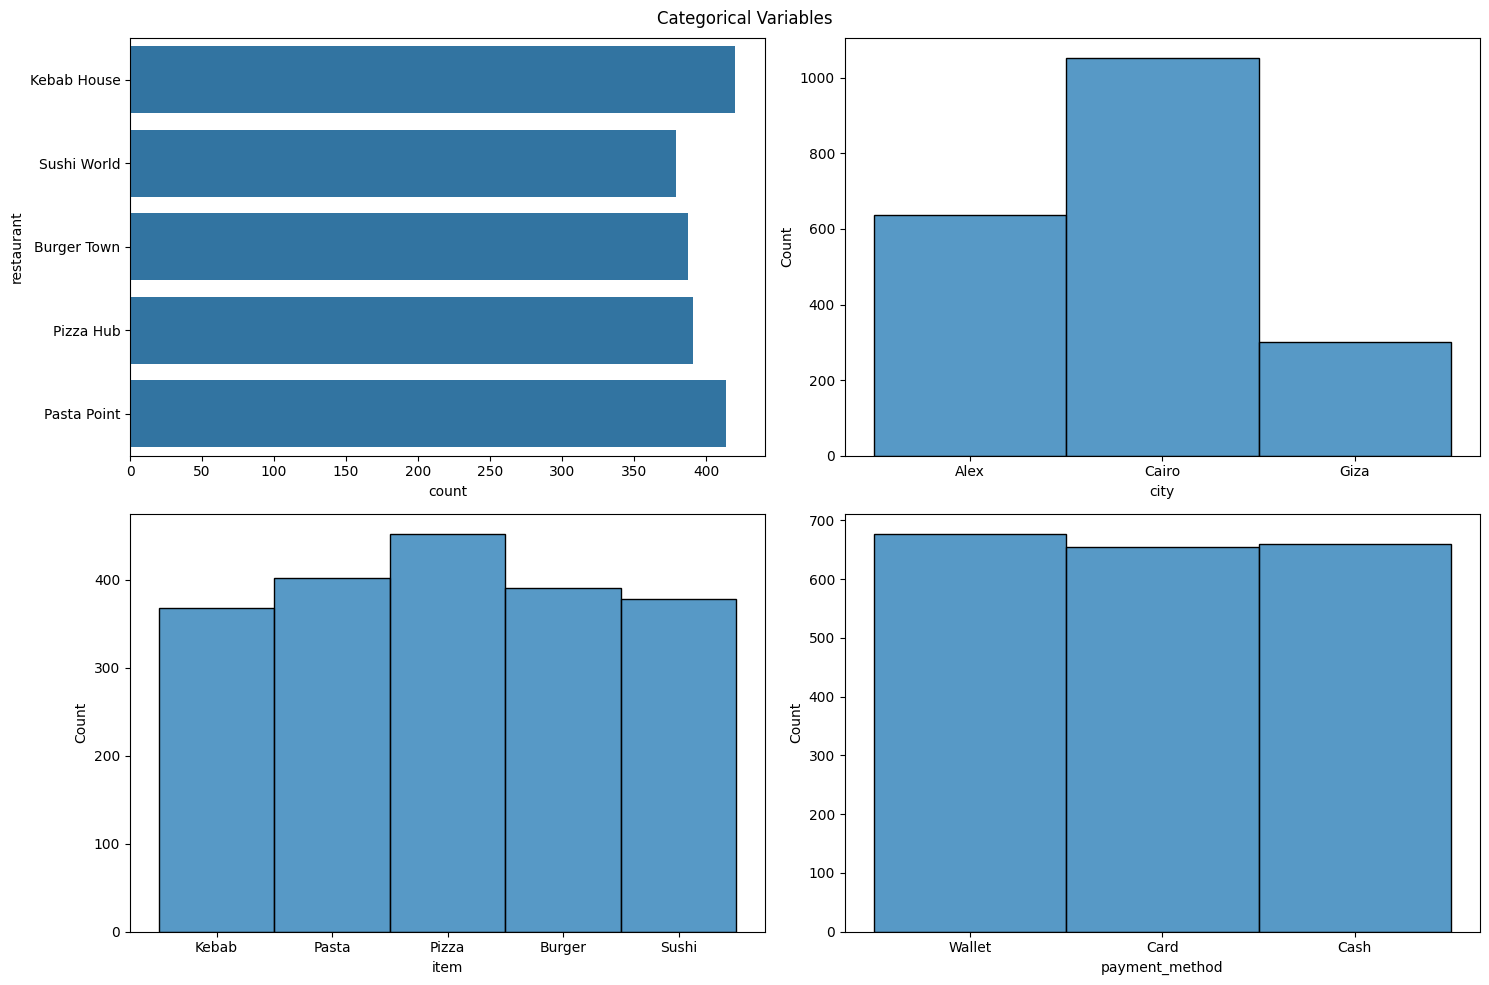

In [20]:
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
sns.countplot(data["restaurant"], ax = ax[0, 0])
sns.histplot(data["city"], ax = ax[0, 1])
sns.histplot(data["item"], ax = ax[1, 0])
sns.histplot(data["payment_method"], ax = ax[1, 1])
fig.suptitle("Categorical Variables")
plt.tight_layout();

All categorical variables have a balanced groups, except "city" most orders are concentrated in "Cairo" and the least orders are in "Giza"

In [24]:
def scatter(x, y):
    sns.scatterplot(data = data, x = x, y = y);

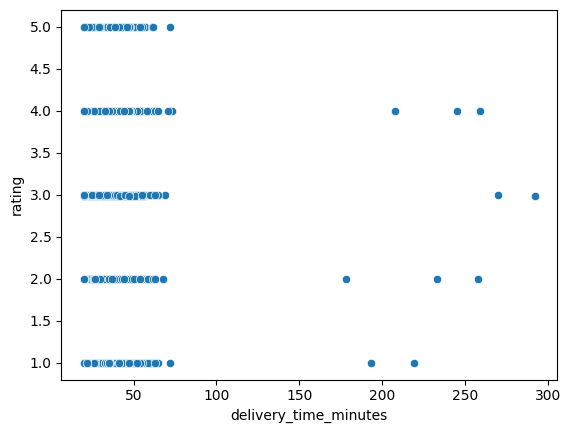

In [26]:
scatter("delivery_time_minutes", "rating")

There isn't any relation between the delivery time and rating

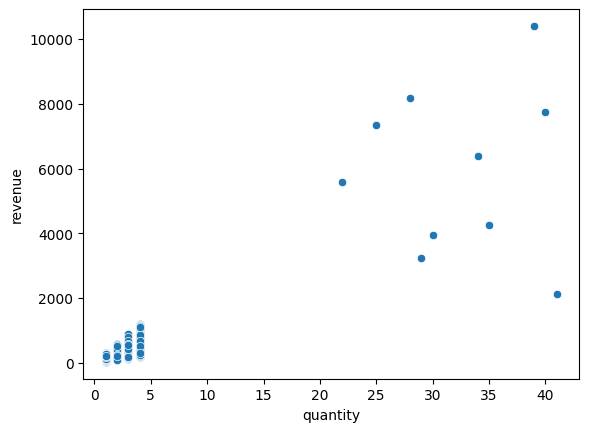

In [27]:
scatter("quantity", "revenue")

There isn't any relation between the quantity and revenue

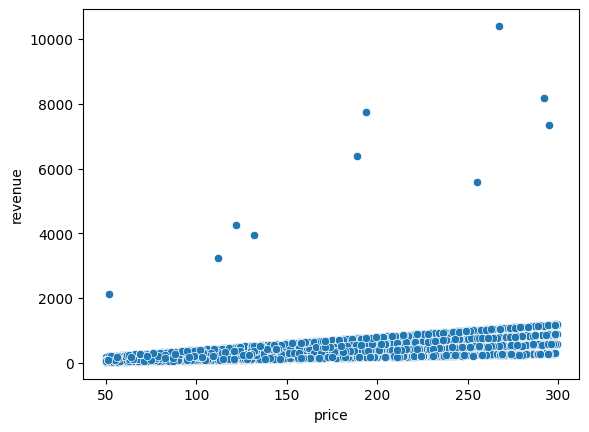

In [28]:
scatter("price", "revenue")

There isn't any relation between the price and revenue

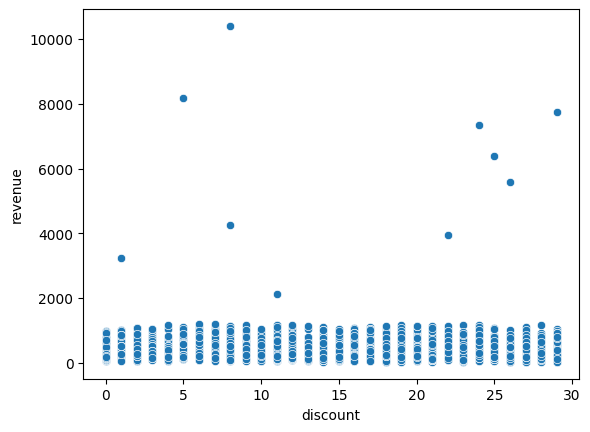

In [30]:
scatter("discount", "revenue")

There isn't any relation between the discount and revenue

In [34]:
def bar(x, y):
    sns.barplot(data = data, x = x, y = y);

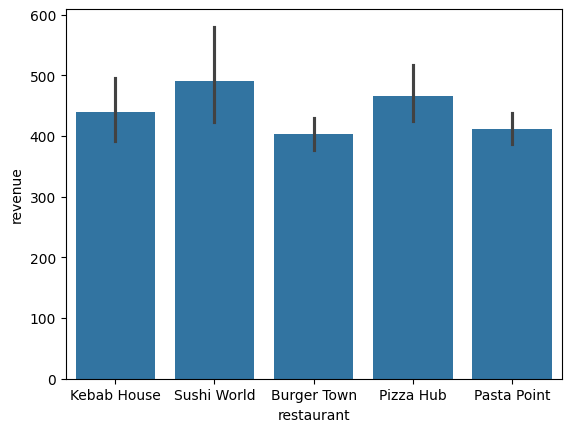

In [36]:
bar("restaurant", "revenue")

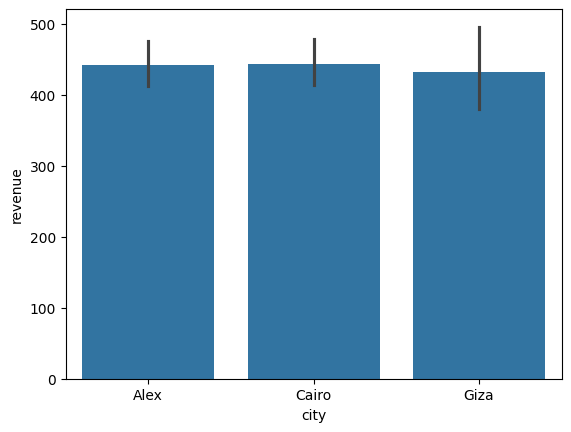

In [38]:
bar("city", "revenue")

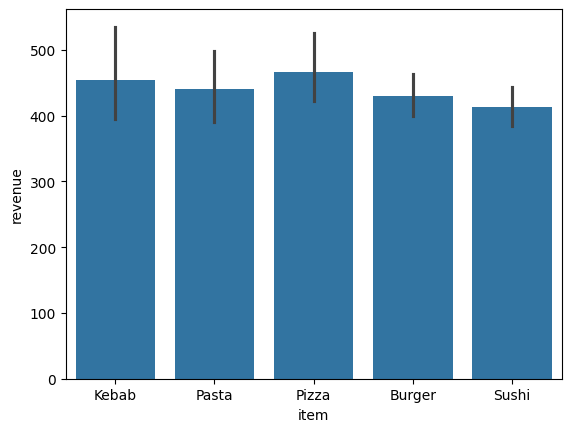

In [37]:
bar("item", "revenue")

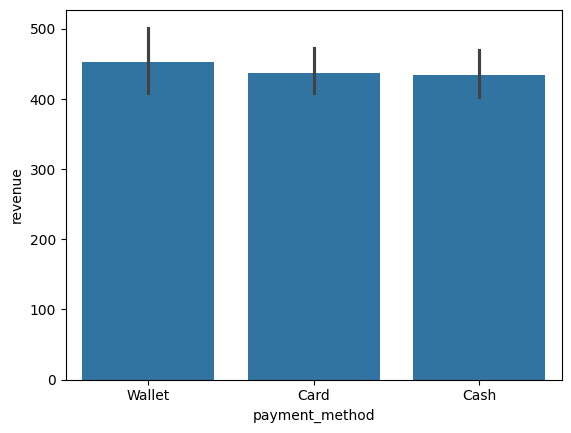

In [40]:
bar("payment_method", "revenue")

In [48]:
def count(x, hue):
    sns.countplot(data = data, x = x, hue = hue);

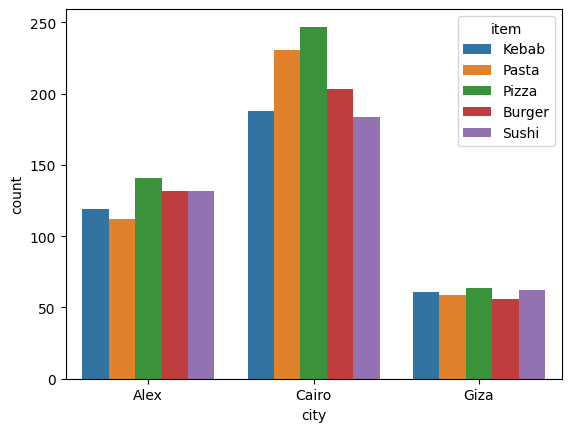

In [50]:
count("city", "item")

There is a relation between the city and the item, Ex: "Pasta" is more ordered in Cairo relative to Alex and Giza

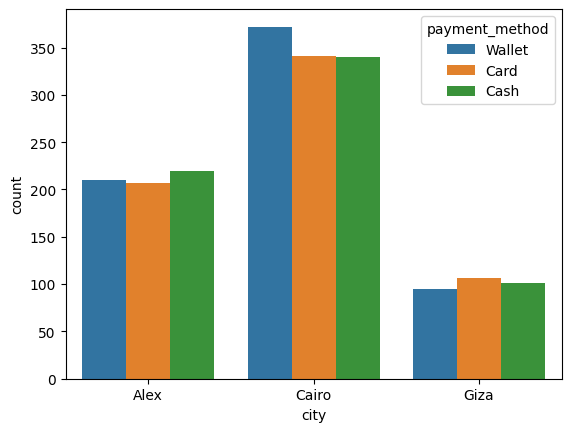

In [51]:
count("city", "payment_method")

There is a relation between the city and the payment method, Ex: "Wallet" is the most common method in Cairo relative to Alex and Giza

In [58]:
def subset(x):
    return data.groupby(x)[["delivery_time_minutes", "quantity", "price", "discount", "rating", "revenue"]].mean()

In [59]:
subset("city")

,delivery_time_minutes,quantity,price,discount,rating,revenue
city,,,,,,
Alex,35.885220,2.654088,172.515723,14.488994,3.027491,442.677673
Cairo,36.083571,2.676163,172.109212,14.651472,2.969633,443.873694
Giza,36.562914,2.579470,171.612583,14.231788,2.925993,432.281457


In [60]:
subset("restaurant")

,delivery_time_minutes,quantity,price,discount,rating,revenue
restaurant,,,,,,
Burger Town,36.617571,2.493540,168.870801,14.506460,3.009051,403.361757
Kebab House,34.121429,2.628571,172.297619,15.176190,3.070683,439.090476
Pasta Point,36.975845,2.555556,169.190821,14.103865,2.890370,412.103865
Pizza Hub,37.225064,2.703325,177.145780,14.176471,2.930240,465.838875
Sushi World,35.609499,2.905013,173.485488,14.699208,3.006943,491.340369


In [62]:
data["delivery_performance_group"] = pd.cut(data["delivery_time_minutes"], labels = ["high", "medium", "low"], bins = 3)
subset("delivery_performance_group")

,delivery_time_minutes,quantity,price,discount,rating,revenue
delivery_performance_group,,,,,,
high,35.08632,2.654215,172.369006,14.553761,2.983431,442.250379
medium,185.50000,2.000000,172.500000,14.500000,1.500000,330.500000
low,248.00000,2.875000,121.250000,10.125000,2.872697,341.500000


In [63]:
data.to_csv("data/Food_Delivery_Cleaned.csv", index = False)